# Import Libraries

In [ ]:
import os
from collections import Counter

# Load image data
from torchvision import transforms
from torchvision.datasets import ImageFolder

import torch
from torch.utils.data import random_split

from util.ImageProcessor import CustomImageTransform
from util.DatasetProcessor import BalancedImageDataset

# Data Description
The dataset is separated as follows:
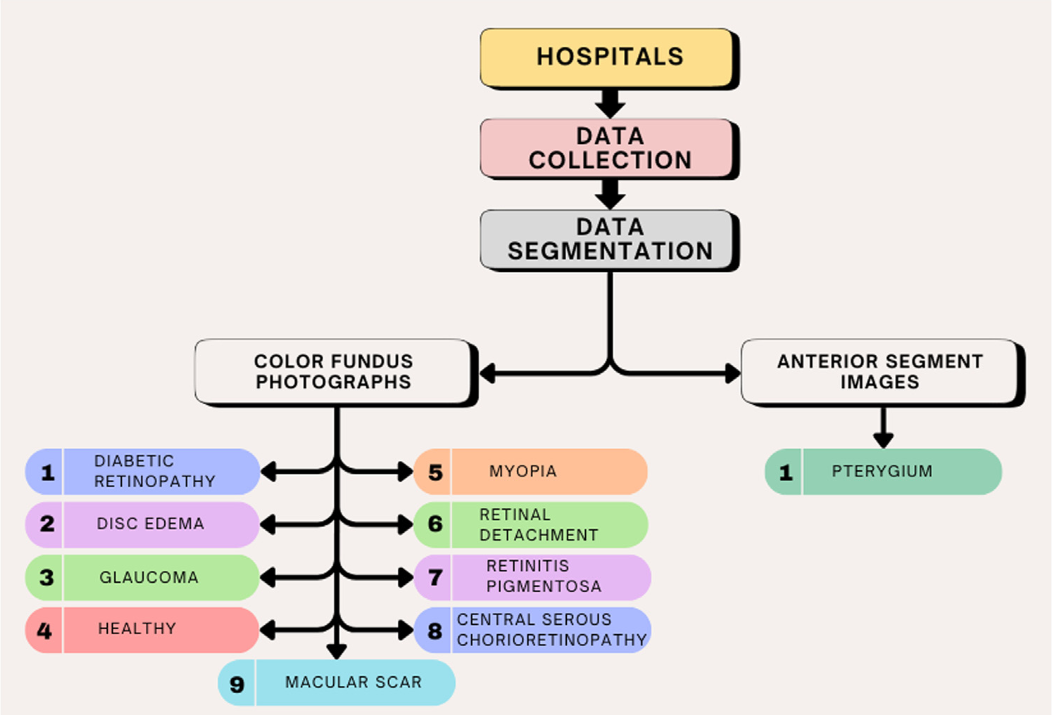

Because of that we will only use the data collected from `color-fundus-chronographs` and `normal` class. We will drop the `pterygium` class. This will help in focusing on the relevant data for our analysis.

# Data Loading

## Original Dataset Loading

In [2]:
transform_pipeline = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),  # Convert PIL Image to tensor and normalize to [0, 1]
        CustomImageTransform(
            clahe_clip_limit=2.0,
            clahe_tile_grid_size=(8, 8),
            gaussian_kernel_size=5,
            gaussian_sigma=1.0,
            median_kernel_size=5
        )
    ])

# Load the dataset
dataset = ImageFolder(root='Data/Original_Dataset/', transform=transform_pipeline)

In [3]:
class_map = {
    'Healthy' : 0,
    'Central Serous Chorioretinopathy-Color Fundus' : 1,
    'Diabetic Retinopathy' : 2,
    'Disc Edema' : 3,
    'Glaucoma' : 4,
    'Macular Scar' : 5,
    'Myopia' : 6,
    'Retinal Detachment' : 7,
    'Retinitis Pigmentosa' : 8
}

# Trasform the dataset class map with the new class map
dataset.class_to_idx = class_map

In [4]:
augmented_dataset = ImageFolder(root='Data/Augmented_Dataset/', transform=transform_pipeline)

augmented_dataset.class_to_idx = class_map

# PreProcessing

## Split Data into 50% Train 25% Validation 25% Test

In [11]:
train_size = int(0.5 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

val_size = int(0.5 * len(val_dataset))
test_size = len(val_dataset) - val_size
val_dataset, test_dataset = random_split(val_dataset, [val_size, test_size])

## Class Balancing by Adding Underrepresented Classes in the Original Dataset with Augmented Dataset

In [13]:
balanced_train_dataset = BalancedImageDataset(original_dataset=train_dataset, augmented_dataset=augmented_dataset)

Analyzing class distribution in original dataset...


100%|██████████| 2659/2659 [04:44<00:00,  9.36it/s]


Analyzing class distribution in augmented dataset...
Building balanced dataset...
Adding samples from original dataset...


Adding original samples: 100%|██████████| 2659/2659 [03:20<00:00, 13.28it/s]


Balancing classes with augmented samples...


Balancing classes: 100%|██████████| 9/9 [00:00<00:00, 529.39it/s]

Balanced dataset created with 6705 samples


In [14]:
# Check class distribution in balanced dataset
class_counts = Counter(balanced_train_dataset.targets)
print("Class distribution in balanced dataset:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Class distribution in balanced dataset:
4: 745
6: 745
1: 745
3: 745
5: 745
2: 745
8: 745
7: 745
0: 745


# Export The Balanced Dataset

In [16]:
# Save the balanced dataset
os.makedirs('Data/Final_Dataset', exist_ok=True)
torch.save(balanced_train_dataset, 'Data/Final_Dataset/balanced_train_dataset_dataset.pt')
torch.save(train_dataset, 'Data/Final_Dataset/train_dataset.pt')
torch.save(val_dataset, 'Data/Final_Dataset/val_dataset.pt')
torch.save(test_dataset, 'Data/Final_Dataset/test_dataset.pt')
# Save the class map
torch.save(class_map, 'Data/Final_Dataset/class_map.pt')